# UdaciMed | Notebook 1: Baseline Analysis

Welcome to UdaciMed! You are a Machine Learning Engineer tasked with optimizing our chest X-ray pneumonia detection model for production deployment.

- **The challenge**: Before our new model can be approved for production, we must verify that it meets our strict performance SLAs. Deploying an unoptimized model could lead to high operational costs and poor performance across our diverse hardware fleet—from shared T4 GPU cloud instances to portable clinic devices.

- **Your mission**: Optimize the model to pass _UdaciMed's Universal Performance Standard_, a strict production service level agreement (SLA) that must be met using the universally compatible ONNX format on our standardized target device.

### **Optimization goals**

Your goal is to ensure the production model meets these production targets on our standardized development machine:

- **< 0.4 GFLOPs per sample**: Floating Point Operations determine computational cost - reducing FLOPs is the most critical step toward broad-platform efficiency.
- **< 100MB peak memory footprint**: Total memory consumption (parameters + activations + workspace) during inference - essential for running the model on memory-constrained edge devices and for enabling cost-effective multi-model environments in the cloud.
- **< 3ms latency**: This ensures a real-time user experience. We will measure both *amortized latency* (average time per sample in a large batch) and *true latency* (time for a single-image inference), as both are important for different use cases.
- **> 2000 samples/second throughput**: This specific target is for our high-performance hardware, like the reference T4 GPU. Meeting this goal proves the model is cost-effective and scalable for high-volume, server-side screening workflows.
- **> 98% sensitivity***: This is a non-negotiable clinical safety requirement. We must ensure that a threshold percentage of all true pneumonia cases are correctly identified. All optimizations must be validated against this metric.

#### **A note on our standardized target device**

All performance targets in this project must be met on our official _"standardized target device."_ This is an NVIDIA T4 GPU, a common and versatile datacenter GPU that represents a typical cloud deployment environment.

By using a single, consistent hardware profile (NVIDIA T4 with 16GB VRAM, CUDA 12.4) for all our performance SLAs, we can:

- *Ensure Reproducible Results*: Anyone on the team can validate performance and get consistent measurements.

- *Create a Reliable Benchmark*: It provides a stable baseline to measure the impact of every optimization we make.

If a model can meet our strict, universal performance standards on this reference hardware, we are confident it will perform well across our entire fleet of production devices.

---

Through this notebook, you will build the foundation for our optimization strategy by:

1.  **Establishing baseline performance** with comprehensive profiling.
2.  **Analyzing the primary bottlenecks**, distinguishing between compute, parameter memory, and activation memory.
3.  **Identifying optimization opportunities** in both the model architecture and the deployment configuration.

**Let's set up an optimization vision for UdaciMed's next-generation diagnostic platform!**


> **_\*Understanding medical AI requirements_**:
> 
> In medical AI, sensitivity (recall) is often more critical than overall accuracy. Missing a pneumonia case (false negative) can be life-threatening, while a false positive "only" leads to additional human review. This is why we prioritize sensitivity as our safety constraint.

## Step 1: Set up the environment
The first step is to import all libraries and internal functionalities (from `utils`). 

Additionally, we set `pytorch` to use CUDA GPU if available (not only for faster execution, but also for benchmarking, as this will be our final deployment target!) and we include deterministic mode for reproducible benchmarking.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import core libraries
import torch
import torch.nn as nn
import inspect
import numpy as np
import os
import pickle
from pprint import pprint
import random
from torchsummary import summary
import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from utils.data_loader import (
    load_pneumoniamnist, 
    get_dataset_info, 
    explore_dataset_splits,
    visualize_sample_images,
    get_sample_batch
)
from utils.model import (
    create_baseline_model,
    get_model_info,
    count_parameters_by_type,
    train_baseline_model,
    plot_training_history
)
from utils.evaluation import (
    evaluate_with_multiple_thresholds
)
from utils.profiling import (
    PerformanceProfiler,
    get_gpu_info,
    check_environment,
    measure_time
)
from utils.visualization import (
    plot_dataset_distribution,
    plot_performance_profile,
    plot_operation_breakdown,
    plot_batch_size_comparison,
)

# Check environment and GPU capabilities
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_info = get_gpu_info()
    print(f"GPU: {gpu_info.get('name', 'Unknown')}")
    print(f"GPU Memory: {gpu_info.get('memory_total_gb', 0):.1f} GB")
    print(f"Tensor Core Support: {gpu_info.get('tensor_core_support', False)}")
else:
    print("WARNING: CUDA not available - profiling will be limited")

Using device: cpu


In [3]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


## Step 2: Load and analyze the dataset
Now, we can get started with our baseline model set-up by loading the data and understanding its characteristics. 

For this project, we use the PneumoniaMNIST dataset from [MedMNIST](https://medmnist.com/). PneumoniaMNIST provides a standardized, validated dataset for pneumonia detection research. Its 64x64 resolution balances clinical detail with computational efficiency, making it ideal for optimization studies while maintaining diagnostic relevance.

In [4]:
# Get dataset information
dataset_info = get_dataset_info(use_binary=True)
print("PneumoniaMNIST Dataset Information:")
for key, value in dataset_info.items():
    print(f"   {key.replace('_', ' ').title()}: {value}")

PneumoniaMNIST Dataset Information:
   Name: PneumoniaMNIST
   Task: Binary classification (Normal vs Pneumonia)
   Classes: ['Normal', 'Pneumonia']
   Num Classes: 2
   Source: Chest X-ray Images (Pneumonia) from Kaggle
   Original Size: Various sizes (medical imaging protocols vary)
   Processed Sizes: [28, 64, 128, 224]
   Medical Context: Pneumonia detection in chest X-rays for clinical decision support
   Samples: {'train': 4708, 'val': 524, 'test': 624}
   Total Samples: 5856
   Clinical Significance: Early pneumonia detection critical for patient outcomes
   Preprocessing Note: ImageNet normalization applied for transfer learning optimization


In [5]:
# Define configuration for baseline analysis
CONFIG = {
    'image_size': 64,  # Balanced for for memory usage and model accuracy
    'num_classes': 2,  # Binary classification: normal vs pneumonia
    'batch_size': 32,  # Balanced for memory usage and training stability
    'subset_size': None,  # Use full dataset for production-representative results
}

# Load the dataset with optimized settings
print("Loading PneumoniaMNIST dataset...")

with measure_time("Dataset loading"):
    train_loader = load_pneumoniamnist(
        split="train", download=True, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.7 if CONFIG['subset_size'] is not None else None
    )
    
    val_loader = load_pneumoniamnist(
        split="val", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )
    
    test_loader = load_pneumoniamnist(
        split="test", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None
    )

print(f"Dataset loaded: {CONFIG['image_size']}x{CONFIG['image_size']} images, batch_size={CONFIG['batch_size']}")

Loading PneumoniaMNIST dataset...


  0%|          | 0/20606998 [00:00<?, ?it/s]

  0%|          | 32768/20606998 [00:00<01:57, 174764.44it/s]

  0%|          | 65536/20606998 [00:00<03:14, 105353.21it/s]

  1%|          | 163840/20606998 [00:00<01:23, 243709.47it/s]

...

 73%|███████▎  | 15106048/20606998 [00:03<00:00, 7793161.43it/s]

 82%|████████▏ | 16941056/20606998 [00:03<00:00, 8322019.85it/s]

 91%|█████████▏| 18841600/20606998 [00:03<00:00, 8822560.76it/s]

100%|██████████| 20606998/20606998 [00:03<00:00, 5339432.74it/s]

⏱️ Dataset loading took 5801.10 ms
Dataset loaded: 64x64 images, batch_size=32


Analyzing dataset distribution...



Dataset Summary: {'train': {'total': 4708, 'class_stats': {'normal': 1214, 'pneumonia': 3494, 'type': 'binary'}, 'normal': 1214, 'pneumonia': 3494, 'pneumonia_ratio': 0.7421410365335599}, 'val': {'total': 524, 'class_stats': {'normal': 135, 'pneumonia': 389, 'type': 'binary'}, 'normal': 135, 'pneumonia': 389, 'pneumonia_ratio': 0.7423664122137404}, 'test': {'total': 624, 'class_stats': {'normal': 234, 'pneumonia': 390, 'type': 'binary'}, 'normal': 234, 'pneumonia': 390, 'pneumonia_ratio': 0.625}}


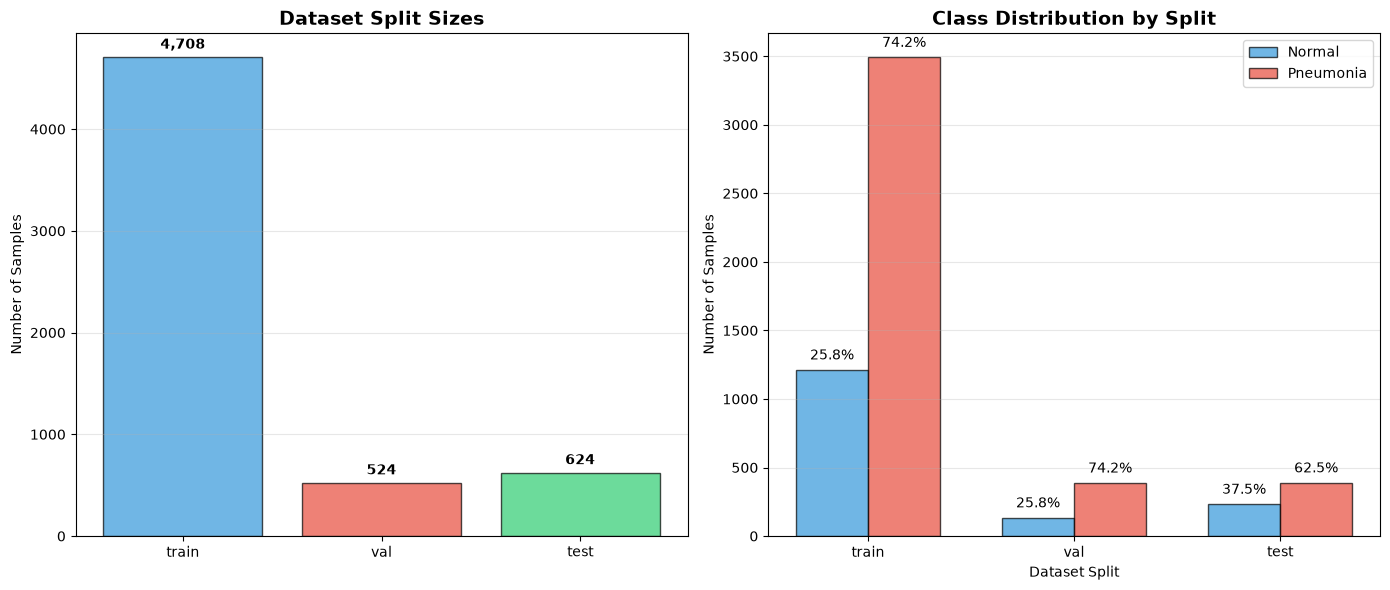

In [6]:
# Analyze dataset distribution for class imbalance considerations
print("Analyzing dataset distribution...")
dataset_splits = explore_dataset_splits(train_loader, val_loader, test_loader)
print(f"\nDataset Summary: {dataset_splits}")

# Visualize dataset distribution
plot_dataset_distribution(dataset_splits)

> **_The impact of class imbalance_**
> 
> Medical datasets often have class imbalance. This affects optimization because:
> 
> - Models may focus compute on majority class features
> - Batch composition affects memory usage patterns
> - Some optimization techniques (like pruning) may disproportionately affect minority class performance

Sample chest X-ray images:


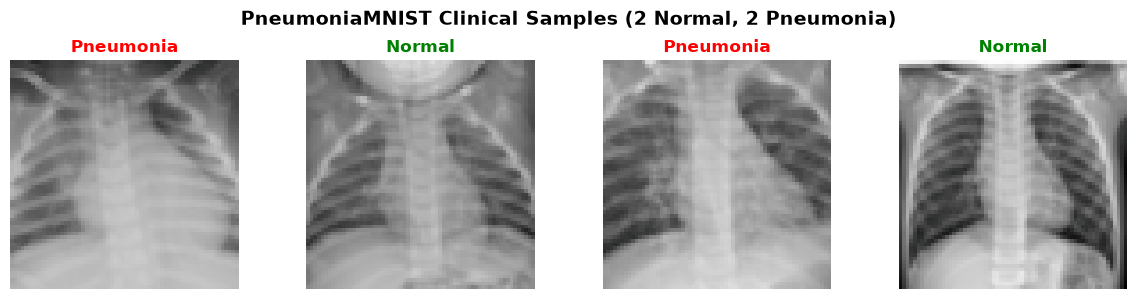

Displayed 4 images: 2 normal, 2 pneumonia


In [7]:
# Visualize sample images to understand data characteristics
print("Sample chest X-ray images:")
visualize_sample_images(train_loader, num_samples=4)

## Step 3: Create and analyze the baseline model
We will use [ResNet-18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) as our baseline - a popular choice for medical imaging that balances accuracy and efficiency.

The original model structure is architected for ImageNet (1000 classes), so we modify the model with a custom head to support our new classification task.

In [8]:
# Create the baseline ResNet-18 model
print("Creating ResNet-18 baseline model...")

baseline_model = create_baseline_model(
    num_classes=CONFIG['num_classes'], 
    input_size=CONFIG['image_size'], 
    pretrained=False  # Training from scratch for fair optimization comparison
)
baseline_model = baseline_model.to(device)

print(f"Baseline model created and deployed to {device}")
print(f"   Architecture: {baseline_model.architecture_name}")

Creating ResNet-18 baseline model...


Baseline model created and deployed to cpu
   Architecture: ResNet-18-Adaptive


In [9]:
# Get model information
model_info = get_model_info(baseline_model)

print(f"\nModel Information:")
print(f"   Architecture: {model_info['architecture']}")
print(f"   Total Parameters: {model_info['total_parameters']:,}")
print(f"   Model Size: {model_info['model_size_mb']:.1f} MB")
print(f"   Input Size: {model_info['input_size']}x{model_info['input_size']}")

# Analyze layer composition 
layer_breakdown = model_info['layer_breakdown']
print(f"\nLayer Composition:")
print(f"   Convolution Layers: {layer_breakdown['conv_layers']['count']} ({layer_breakdown['conv_layers']['total_params']:,} params)")
print(f"   Linear Layers: {layer_breakdown['linear_layers']['count']} ({layer_breakdown['linear_layers']['total_params']:,} params)")
print(f"   Normalization Layers: {layer_breakdown['norm_layers']['count']}")
print(f"   Activation Types: {', '.join(layer_breakdown['activation_layers']['types'])}")

# Get parameter distribution
if 'parameter_distribution' in layer_breakdown:
    param_dist = layer_breakdown['parameter_distribution']
    print(f"\nParameter Distribution:")
    print(f"   Convolution: {param_dist['conv_percentage']:.2f}%")
    print(f"   Linear: {param_dist['linear_percentage']:.2f}%")


Model Information:
   Architecture: ResNet-18-Adaptive
   Total Parameters: 11,177,538
   Model Size: 42.6 MB
   Input Size: 64x64

Layer Composition:
   Convolution Layers: 20 (11,166,912 params)
   Linear Layers: 1 (1,026 params)
   Normalization Layers: 20
   Activation Types: ReLU

Parameter Distribution:
   Convolution: 99.99%
   Linear: 0.01%


In [10]:
# Display the model architecture
summary(baseline_model, input_size=(3, CONFIG["image_size"], CONFIG["image_size"]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

> **_Brainstorming time: Optimizations by layer type_**
> 
> Try to remember from the course, which architectural optimizations most benefit each layer type? Looking at the layer composition, our model is convolution-heavy - this is your starting point!

## Step 4: Train and evaluate baseline model
Now, we define the baseline model and evaluate its performance on key accuracy metrics - all future optimizations should maintain a similar clinical performance standard.

Establishing robust baseline metrics is crucial for medical AI. Any optimization must preserve clinical safety while improving computational efficiency.

Starting baseline model training for pneumonia detection...
   Config: 10 epochs, lr=0.0003, wd=0.0001


Epoch 1/10 [Train]:   0%|                                                   | 0/148 [00:00<?, ?it/s]

Epoch 1/10 [Train]:   0%|                            | 0/148 [00:09<?, ?it/s, Loss=0.719, Acc=53.1%]

Epoch 1/10 [Train]:   1%|▏                   | 1/148 [00:09<23:53,  9.75s/it, Loss=0.719, Acc=53.1%]

Epoch 1/10 [Train]:   1%|▏                   | 1/148 [00:17<23:53,  9.75s/it, Loss=0.676, Acc=68.8%]

...

Epoch 10/10 [Val]:  88%|██████████████████▌  | 15/17 [00:13<00:01,  1.16it/s, Loss=0.065, Acc=97.5%]

Epoch 10/10 [Val]:  94%|███████████████████▊ | 16/17 [00:13<00:00,  1.18it/s, Loss=0.065, Acc=97.5%]

Epoch 10/10 [Val]:  94%|███████████████████▊ | 16/17 [00:14<00:00,  1.18it/s, Loss=0.061, Acc=97.5%]

Epoch 10/10 [Val]: 100%|█████████████████████| 17/17 [00:14<00:00,  1.45it/s, Loss=0.061, Acc=97.5%]

   Epoch 10: Train Acc  99.2% | Val Acc  97.5% | Train Loss 0.0219 | Val Loss 0.0614 | LR 0.000000
Training completed! Best validation accuracy: 97.90%


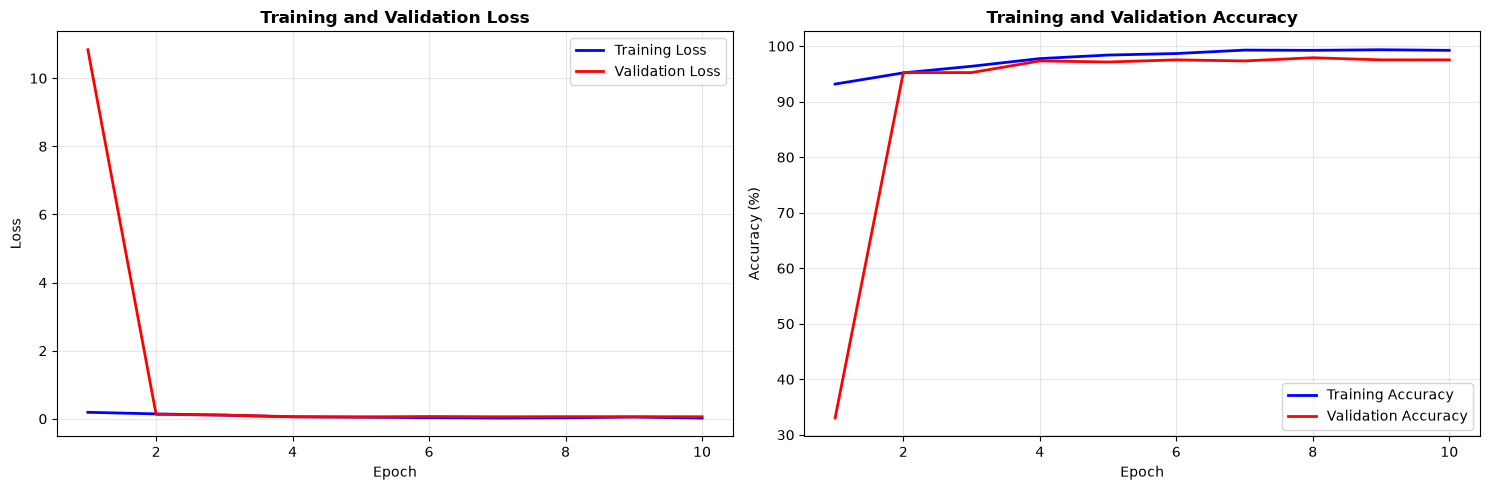


Training Summary:
   Best Validation Accuracy: 97.9%
   Total Epochs: 10
   Final Training Accuracy: 99.2%
   Final Validation Accuracy: 97.5%


In [11]:
# Training configuration
TRAINING_CONFIG = {
    'num_epochs': 10,           # Sufficient for convergence analysis
    'learning_rate': 0.0003,    # Conservative rate for stable training
    'lr_step_size': 3,          # Learning rate decay schedule
    'weight_decay': 1e-4,       # Regularization for generalization
    'patience': 3               # Early stopping for efficiency
}

# Training checkpoints and profiling results are stored under ../results
os.makedirs('../results', exist_ok=True)

# Train the model
baseline_model, training_history = train_baseline_model(
    baseline_model, train_loader, val_loader, device, TRAINING_CONFIG
)

# Plot training curves with analysis
plot_training_history(training_history)

> **Training insights: What does the training history tell us?**
> 
> The initial low validation accuracy is due to extreme overfitting due to the small dataset size in comparison to the model's parameter size. The presence of early plateaus and fast convergence also highlight that the architecture has high representational power - we can likely apply aggressive optimization without accuracy degradation.

In [12]:
# Evaluate model performance with multiple thresholds 
print(f"Running eval benchmark on {dataset_splits['test']['total']} test samples ...")
eval_results = evaluate_with_multiple_thresholds(baseline_model, test_loader, device, [0.4, 0.7])

Running eval benchmark on 624 test samples ...

Evaluating with threshold 0.4:


Clinical Evaluation Results (threshold: 0.400):
   Accuracy:  86.1%
   Precision: 81.8% (PPV - Positive Predictive Value)
   Recall:    100.0% (Sensitivity)
   F1 Score:  90.0%
   AUC-ROC:   0.969

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     147
   False Positives (Normal misclassified):            87
   False Negatives (Pneumonia missed):                 0
   True Positives (Pneumonia correctly detected):   390

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     100.0% (detects 100.0% of pneumonia cases)
   Specificity (True Negative Rate):     62.8% (correctly identifies 62.8% of normal cases)
   PPV (Positive Predictive Value):      81.8% (when model predicts pneumonia, it's correct 81.8% of time)
   NPV (Negative Predictive Value):      100.0% (when model predicts normal, it's correct 100.0% of time)

Clinical Significance:
   False Negative Rate: 0.0% (missed pneumonia cases - critical for patient safety)
   False Posi

Clinical Evaluation Results (threshold: 0.700):
   Accuracy:  88.5%
   Precision: 84.9% (PPV - Positive Predictive Value)
   Recall:    99.2% (Sensitivity)
   F1 Score:  91.5%
   AUC-ROC:   0.969

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     165
   False Positives (Normal misclassified):            69
   False Negatives (Pneumonia missed):                 3
   True Positives (Pneumonia correctly detected):   387

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     99.2% (detects 99.2% of pneumonia cases)
   Specificity (True Negative Rate):     70.5% (correctly identifies 70.5% of normal cases)
   PPV (Positive Predictive Value):      84.9% (when model predicts pneumonia, it's correct 84.9% of time)
   NPV (Negative Predictive Value):      98.2% (when model predicts normal, it's correct 98.2% of time)

Clinical Significance:
   False Negative Rate: 0.8% (missed pneumonia cases - critical for patient safety)
   False Positive 

> **Clinical threshold selection**
>
> Different thresholds optimize for different clinical scenarios. Lower thresholds (0.4) maximize sensitivity for screening, while higher thresholds (0.7) balance precision and recall for diagnostic confirmation.

## Step 5: Profile baseline model for latency, throughput, and memory usage

Comprehensive performance profiling forms the foundation of our optimization strategy. We will measure all key metrics that impact multi-tenant deployment.

In [13]:
# Initialize performance profiler
profiler = PerformanceProfiler(device=str(device))
print(f"Performance profiler initialized for {device}")

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(val_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"\nSample batch for profiling:")
print(f"   Batch shape: {sample_images.shape}")
print(f"   Memory usage: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")

Performance profiler initialized for cpu



Sample batch for profiling:
   Batch shape: torch.Size([32, 3, 64, 64])
   Memory usage: 1.5 MB


In [14]:
# Profile inference timing
print("Profiling inference timing...")

timing_results = profiler.profile_inference_time(
    model=baseline_model,
    input_tensor=sample_images,
    num_runs=100,       # Sufficient for statistical significance
    warmup_runs=10      # GPU warmup for consistent measurements
)

print(f"\nTiming Results:")
print(f"   Single Sample Latency: {timing_results['single_sample_ms']:.2f} ms")
print(f"   (Single) Batch Throughput: {timing_results['throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Batch Latency: {timing_results['batch_total_ms']:.2f} ms")
print(f"   Batch Throughput: {timing_results['batch_throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Mean Inference Time: {timing_results['mean_ms']:.2f} ms")
print(f"   95th Percentile: {timing_results['p95_ms']:.2f} ms")
print(f"   Standard Deviation: {timing_results['std_ms']:.2f} ms")

Profiling inference timing...



Timing Results:
   Single Sample Latency: 33.10 ms
   (Single) Batch Throughput: 30.2 samples/sec
   Batch Latency: 851.86 ms
   Batch Throughput: 37.6 samples/sec
   Mean Inference Time: 33.10 ms
   95th Percentile: 42.66 ms
   Standard Deviation: 4.28 ms


> **Latency vs throughput trade-offs**
>
> Single sample latency measures real-time diagnostic speed, while batch throughput indicates multi-tenant efficiency. Both metrics are crucial for different deployment scenarios.

In [15]:
# Profile FLOPs for computational efficiency analysis
flops_results = profiler.profile_flops(
    model=baseline_model, 
    input_tensor=sample_images
)

if 'error' in flops_results:
    print(f"FLOPs calculation failed: {flops_results['error']}")
else:
    print(f"\nFLOPs Results:")
    print(f"   Total: {flops_results['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {flops_results['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in flops_results and flops_results['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(flops_results['module_percentage'].items())[:5]:
            gflops = flops_results['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")

Unsupported operator aten::max_pool2d encountered 1 time(s)


Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 58.21 GFLOPs
   Per Sample: 1.82 GFLOPs

   Top Operations (by FLOPs):
     conv: 99.7% (58.03 GFLOPs)
     batch_norm: 0.3% (0.16 GFLOPs)
     upsample_bilinear2d: 0.0% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [16]:
# Profile GPU memory usage
print("Profiling GPU memory usage...")

memory_results = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=sample_images
)

if 'error' not in memory_results:
    print(f"\nMemory Results:")
    print(f"   Peak GPU Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {memory_results['memory_increase_mb']:.1f} MB")

    # Component breakdown
    if 'component_breakdown' in memory_results:
        components = memory_results['component_breakdown']
        print(f"\nMemory Component Breakdown:")
        for component, usage in components.items():
            print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    # torch.cuda memory statistics need a GPU. On a CPU-only machine we fall back to
    # sampling the process resident set size (RSS) during the forward pass and add an
    # analytic breakdown of the main memory consumers so the downstream analysis
    # still has real numbers to work with.
    print(f"CUDA memory profiling unavailable ({memory_results['error']}) - using CPU fallback")
    import gc
    import psutil

    process = psutil.Process()
    gc.collect()
    baseline_rss = process.memory_info().rss / 1024**2

    rss_samples = []
    activation_sizes_mb = []

    def _sample_memory(module, inputs, output):
        rss_samples.append(process.memory_info().rss / 1024**2)
        if torch.is_tensor(output):
            activation_sizes_mb.append(output.numel() * output.element_size() / 1024**2)

    hooks = [m.register_forward_hook(_sample_memory)
             for m in baseline_model.modules() if len(list(m.children())) == 0]
    with torch.no_grad():
        _ = baseline_model(sample_images)
    for h in hooks:
        h.remove()

    model_params_mb = sum(p.numel() * p.element_size() for p in baseline_model.parameters()) / 1024**2
    input_mb = sample_images.numel() * sample_images.element_size() / 1024**2

    memory_results = {
        'peak_memory_mb': max(rss_samples),
        'memory_increase_mb': max(rss_samples) - baseline_rss,
        'component_breakdown': {
            'model_parameters_mb': model_params_mb,
            'input_tensor_mb': input_mb,
            'activations_mb': sum(activation_sizes_mb),
            'largest_single_activation_mb': max(activation_sizes_mb),
        }
    }

    print(f"\nMemory Results (CPU process-level fallback):")
    print(f"   Peak Process Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase During Inference: {memory_results['memory_increase_mb']:.1f} MB")
    print(f"\nMemory Component Breakdown (analytic):")
    for component, usage in memory_results['component_breakdown'].items():
        print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")


Profiling GPU memory usage...
CUDA memory profiling unavailable (GPU memory profiling only available with CUDA) - using CPU fallback



Memory Results (CPU process-level fallback):
   Peak Process Memory: 1484.0 MB
   Memory Increase During Inference: 98.0 MB

Memory Component Breakdown (analytic):
   Model Parameters Mb: 42.6 MB
   Input Tensor Mb: 1.5 MB
   Activations Mb: 912.8 MB
   Largest Single Activation Mb: 98.0 MB


> **_Did you notice? A major optimization opportunity hiding in plain sight!_**
> 
> Look carefully at the model summary above. Something doesn't add up with our input/output dimensions...
> 
> Compare the input size we are feeding (64x64) with the first convolution layer's output size. The first Conv2d layer shows output `[-1, 64, 112, 112]` but our input is only 64x64. Where are those extra pixels coming from? Complete the TODO below to find out.
> 
> *Optimization opportunity:* This might be your biggest single optimization win, in both speed and memory usage! Keep this insight in mind as you analyze the profiling results below.

In [17]:
# Inspect the baseline model's forward method using `inspect.get_source()`
print("Manually inspect the ResNetBaseline forward method:")
baseline_model_forward = inspect.getsource(baseline_model.forward)
print(baseline_model_forward)

print("\nDiscussion questions:")
print("1. What happens when height != self.target_size? What is self.target_size set to?")
print("2. How much computational and memory overhead does F.interpolate add? (Hint: Compare 64x64 vs 224x224 pixel counts)")
print("3. Is this interpolation necessary for pneumonia detection, or just a legacy from ImageNet pretraining?")

# Answers, based on the source above:
# 1. Every input that is not already 224x224 is bilinearly upscaled to 224x224
#    (self.target_size = 224, the ImageNet standard).
# 2. 224x224 / 64x64 = 12.25x more pixels, so every convolution downstream does
#    ~12x more work and every activation map holds ~12x more values.
# 3. It is a legacy of ImageNet pretraining. Upscaling a 64x64 source image adds
#    zero information, and we train from scratch here anyway - so the model can
#    process native 64x64 inputs directly once the wrapper stops interpolating.


Manually inspect the ResNetBaseline forward method:
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with adaptive input interpolation for variable input sizes.
        
        Automatically handles input size adaptation to leverage ImageNet pretrained
        features optimally. Critical for medical imaging where input sizes may vary
        across different acquisition protocols.
        
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes) for classification
            
        Note:
            Bilinear interpolation maintains spatial relationships in medical images
            while adapting to the expected ImageNet input size for optimal
            pretrained feature utilization.
            
        Example:
            >>> model = ResNetBaseline()
            >>> input_tensor = torch.randn(8, 3, 28, 28)  # Vari

In [18]:
# Detailed PyTorch profiler
print("Running detailed PyTorch profiler...")

detailed_results = profiler.profile_with_pytorch_profiler(
    model=baseline_model,
    input_tensor=sample_images,
    num_steps=10        # Sufficient for operation breakdown analysis
)

if 'error' not in detailed_results:
    print(f"\nOperation Breakdown:")
    op_breakdown = detailed_results['operation_breakdown']
    
    # Show top operations for optimization targeting
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1:  # Only show operations > 1%
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
else:
    print(f"WARNING: Detailed profiling error: {detailed_results['error']}")
    detailed_results = {}

Running detailed PyTorch profiler...


STAGE:2026-08-05 00:59:20 1122703:1122703 ActivityProfilerController.cpp:314] Completed Stage: Warm Up


STAGE:2026-08-05 00:59:31 1122703:1122703 ActivityProfilerController.cpp:320] Completed Stage: Collection
STAGE:2026-08-05 00:59:31 1122703:1122703 ActivityProfilerController.cpp:324] Completed Stage: Post Processing



Operation Breakdown:
   Convolution Ops: 89.1%
   Pooling Ops: 4.9%
   Normalization Ops: 3.8%


## Step 6: Visualize and save baseline model's performance

Comprehensive visualization helps understand optimization opportunities and track progress across optimization experiments.

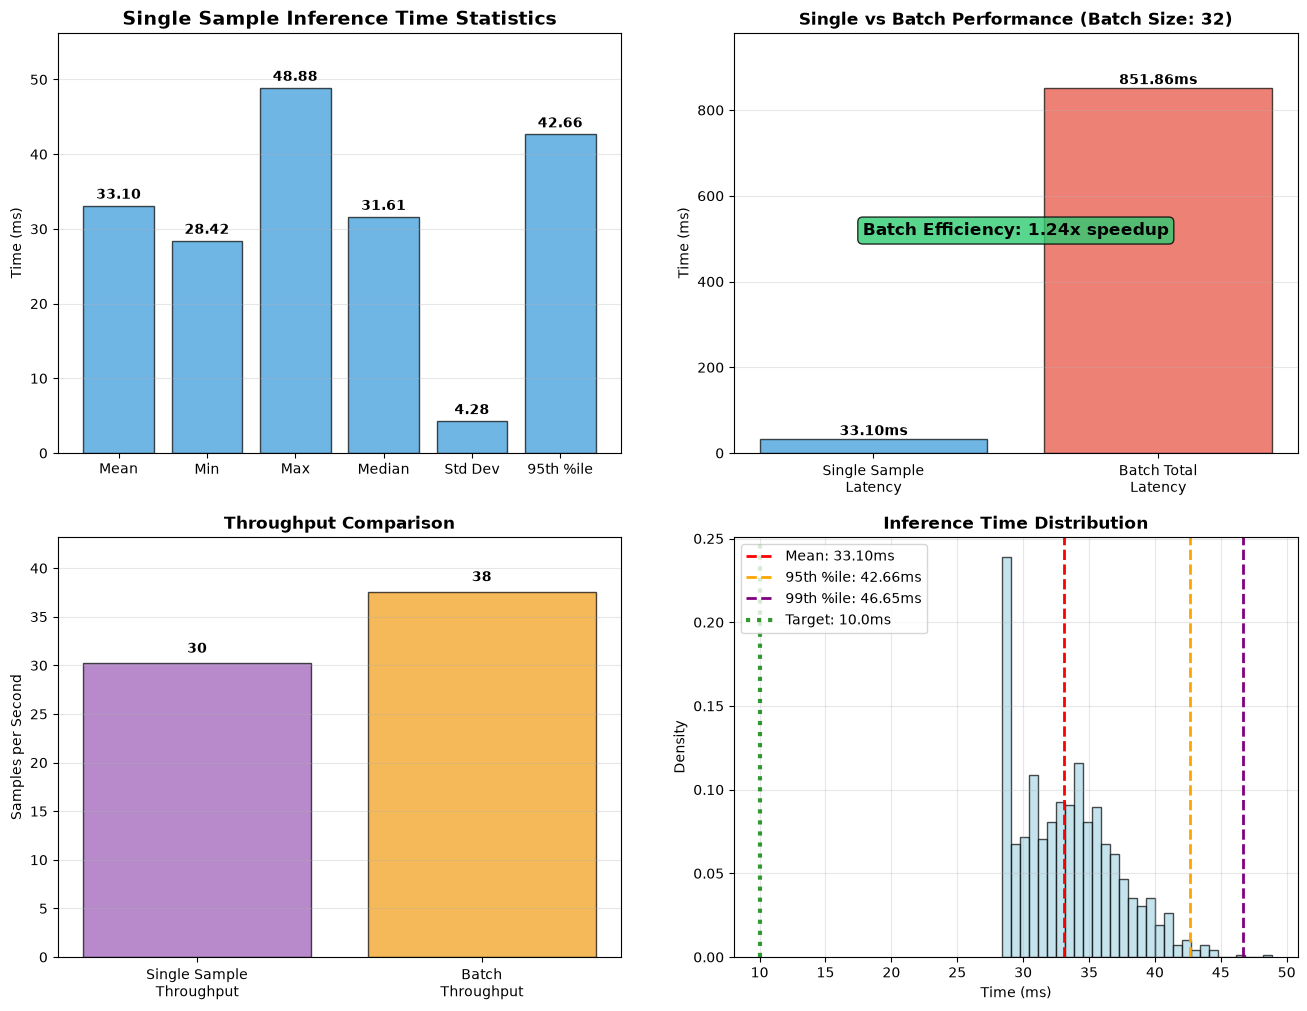

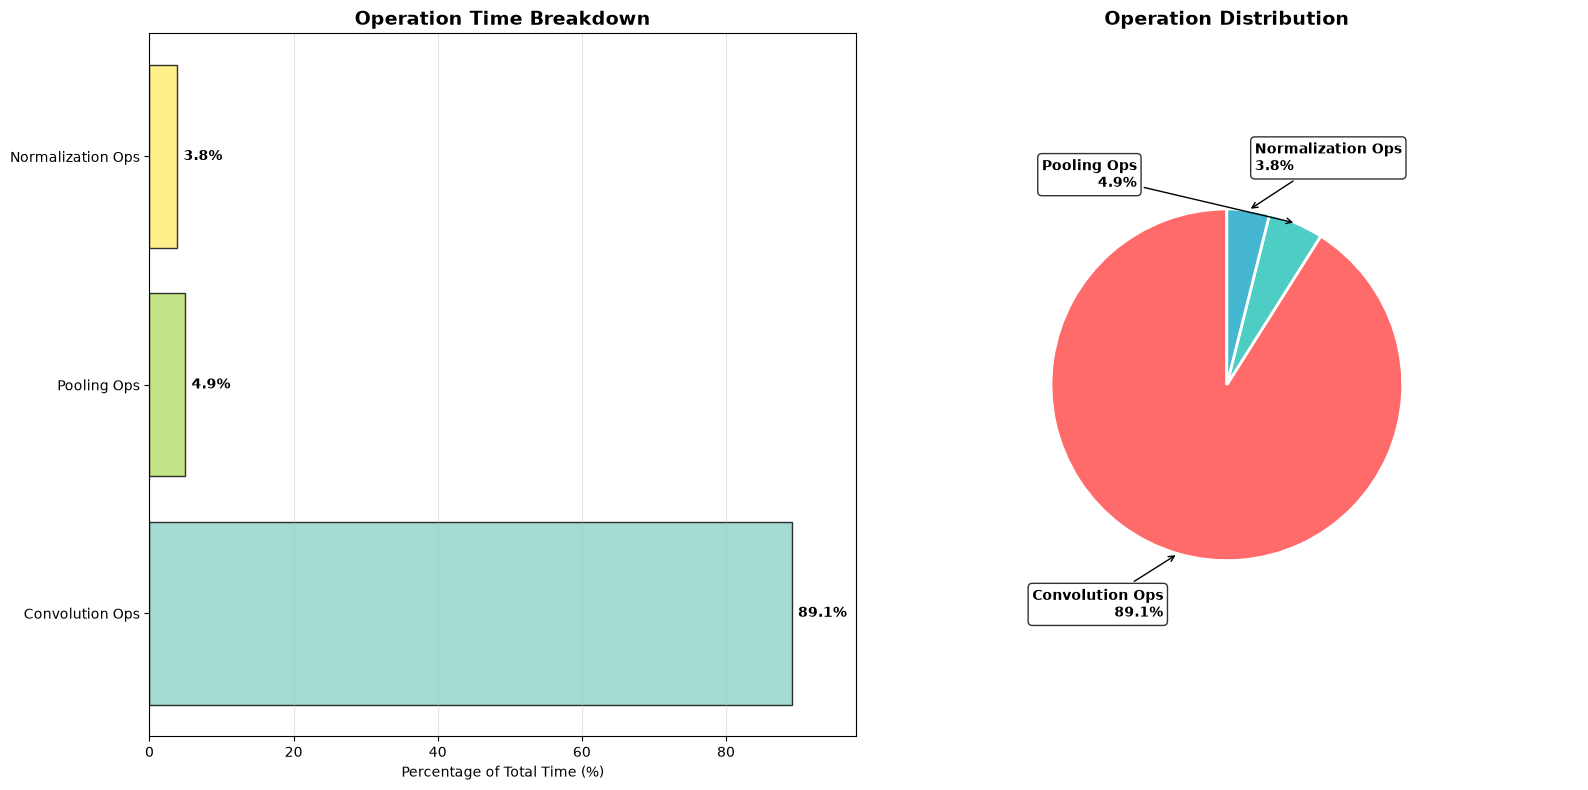

In [19]:
# Visualize performance profile
plot_performance_profile(timing_results)

# Visualize operation breakdown
if detailed_results and 'operation_breakdown' in detailed_results:
    plot_operation_breakdown(detailed_results['operation_breakdown'])
else:
    print("WARNING: Operation breakdown visualization not available")

In [20]:
# Compile baseline results for optimization notebooks
baseline_results = {
    'model_name': 'ResNet-18 Baseline',
    'architecture': model_info['architecture'],
    'total_parameters': model_info['total_parameters'],
    'model_size_mb': model_info['model_size_mb'],
    'config': CONFIG,
    'eval_results': eval_results,
    'timing': timing_results,
    'flops': flops_results,
    'memory': memory_results,
    'operation_breakdown': detailed_results['operation_breakdown'],
    'model_info': model_info,
    'dataset_info': dataset_info,
    'parameter_breakdown': count_parameters_by_type(baseline_model)
}

# Save baseline results
with open('../results/baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Baseline results saved to 'baseline_results.pkl' in the `results/` folder")
print("   This will be used for comparison in optimization notebooks.")

Baseline results saved to 'baseline_results.pkl' in the `results/` folder
   This will be used for comparison in optimization notebooks.


> **Brainstorming time!**
> 
> Based on your profiling results above, analyze the following:
> 
> 1. **Primary bottleneck**: What is the main performance bottleneck - compute time, memory usage, or data transfer?
> 
> 2. **Operation analysis**: Which types of operations (convolution, linear, activation) consume the most time? What percentage?
> 
> 3. **Memory patterns**: How much memory does the model use during inference? What contributes most to memory usage?
> 
> 4. **Optimization priority**: Based on the profiling data, which optimization techniques would you prioritize:
>    - Architecture modifications (channel reduction, efficient blocks)
>    - Precision optimization (mixed precision, quantization)
>    - Hardware acceleration (TensorRT for GPU, ...)
>   
>    _IMPORTANT:_ Did you discover the major inefficiency we hinted at earlier? How much improvement could removing the 64→224 interpolation provide?

---

## Step 7: Analyze optimization opportunities

Now that we have established the baseline performance, it's time for you to conduct a deeper analysis that will guide the optimization strategy. This section contains **two focused analysis checkpoints**:

1. **Architecture optimization analysis** - Identify specific opportunities in the ResNet-18 architecture
2. **Deployment optimization analysis** - Understand hardware acceleration and deployment strategies

Complete these analysis checkpoints to develop your optimization roadmap!

### Analysis checkpoint 1: Architecture optimization opportunities

**Task:** Analyze the ResNet-18 architecture to identify the **top 2 optimization opportunities** from the techniques covered in the course. Available techniques to consider include:
- Grouped convolutions
- Depth-wise separable convolutions
- Inverted residuals with linear bottlenecks
- Low-rank factorization
- Channel organization strategies _(NOTE: this is a hybrid optimization between architecture and hardware)_
- Parameter sharing / weight tying

Feel free to skip programmatic analysis of techniques which you deem to be non-applicable or less performant, but provide an explanation here or in the notebook's final markdown cell.

**IMPORTANT:** Don't forget to also analyze the potential of interpolation removal from the model's forward method!

#### Recommended strategic analysis approach

Calculate the expected impact of applying each technique on parameter reduction programmatically to simplify follow-up analysis. Consider how parameter reduction / architectural improvements for each technique correlate with memory size (activation vs parameters), FLOPs, latency, throughput, and sensitivity to estimate optimization opportunity. HINTS are in each function's signature.

To populate the analysis dictionary with estimated optimiation opportunity, you can either:
1. Programmatically calculate optimization opportunity from parameter reduction and rule-of-thumb
2. Directly add the expected value in the analysis entries, and add a one-line explanation of the value selected as an in-line comment.

In [21]:
## Implement logic for each single technique analysis

def _collect_conv_stats(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """Run one forward pass and record per-layer stats for every Conv2d.

    The wrapper interpolates 64x64 inputs to 224x224 inside forward(), so output
    feature-map sizes have to be measured with hooks instead of derived from the
    nominal input size.
    """
    stats = {}
    handles = []

    def _make_hook(name, module):
        def _hook(mod, inputs, output):
            out_h, out_w = output.shape[-2:]
            k = module.kernel_size[0]
            params = module.in_channels * module.out_channels * k * k // module.groups
            if module.bias is not None:
                params += module.out_channels
            # Multiply-accumulate count per sample for this layer
            flops = (module.in_channels // module.groups) * module.out_channels * k * k * out_h * out_w
            stats[name] = {
                'module': module,
                'kernel_size': k,
                'groups': module.groups,
                'in_channels': module.in_channels,
                'out_channels': module.out_channels,
                'out_hw': (int(out_h), int(out_w)),
                'params': params,
                'flops': flops,
            }
        return _hook

    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            handles.append(module.register_forward_hook(_make_hook(name, module)))

    model.eval()
    with torch.no_grad():
        model(torch.randn(1, *sample_input_shape).to(next(model.parameters()).device))
    for h in handles:
        h.remove()
    return stats


CONV_STATS = _collect_conv_stats(baseline_model)
TOTAL_CONV_FLOPS = sum(s['flops'] for s in CONV_STATS.values())
TOTAL_PARAMS = sum(p.numel() for p in baseline_model.parameters())

# Share of inference time spent inside convolutions, taken from the PyTorch
# profiler run above. Used to convert FLOP savings into wall-clock projections
# via Amdahl's law: only the convolution portion of runtime shrinks.
CONV_TIME_SHARE = detailed_results['operation_breakdown'].get('convolution_ops', 50.0) / 100

# Activation memory measured earlier (falls back to 4x parameter memory, the
# usual rule of thumb for conv nets, if the breakdown is unavailable)
_PARAMS_MB = TOTAL_PARAMS * 4 / 1024**2
ACTIVATIONS_MB = memory_results.get('component_breakdown', {}).get('activations_mb', _PARAMS_MB * 4)


def analyze_grouped_conv_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"]), groups=2):
    """
    Analyze which convolution layers could benefit from grouped convolutions.

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels that are divisible by groups

    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for `groups` division
    Speedup: Proportional to FLOP reduction, but may have overhead from grouped operations on **parallel hardware**
    Throughput: Can be limited by memory bandwidth and **hardware utilization** patterns for grouped operations.

    Also, note that, some backends (like CUDA/CUDNN) may require specific memory formats (e.g., channels_last) and mixed precision to unlock maximum throughput for grouped convolutions.
    This is a known issue: https://discuss.pytorch.org/t/performing-convolutions-in-groups-but-not-grouped-convolution/59412/27
    """
    analysis = {
        'technique': 'Grouped Convolutions',
        'groups': groups,
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    candidates = []
    flops_saved = 0
    params_saved = 0
    for name, s in CONV_STATS.items():
        m = s['module']
        if (s['kernel_size'] > 1 and s['groups'] == 1
                and m.in_channels % groups == 0 and m.out_channels % groups == 0):
            grouped_params = s['params'] // groups
            grouped_flops = s['flops'] // groups
            candidates.append({
                'layer': name,
                'params': s['params'],
                'param_reduction_percent': 100 * (s['params'] - grouped_params) / s['params'],
            })
            params_saved += s['params'] - grouped_params
            flops_saved += s['flops'] - grouped_flops

    flop_reduction_ratio = flops_saved / TOTAL_CONV_FLOPS
    # Grouped kernels underutilize wide parallel hardware, so only credit about
    # half of the FLOP savings as wall-clock improvement
    hardware_efficiency = 0.5
    speedup = 1 / (1 - flop_reduction_ratio * CONV_TIME_SHARE * hardware_efficiency)

    analysis.update({
        'candidate_layers': candidates,
        'total_candidates': len(candidates),
        'avg_param_reduction_percent': round(100 * (1 - 1 / groups), 1),
        'avg_flop_reduction_percent': round(100 * flop_reduction_ratio, 1),
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(params_saved * 4 / 1024**2, 1),
        'estimated_throughput_samples_sec': round(timing_results['throughput_samples_per_sec'] * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'Moderate - halves cross-channel connectivity, needs retraining to recover accuracy'
    })
    return analysis


def analyze_depthwise_separable_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    Analyze which convolution layers could benefit from depthwise separable convolutions.

    HINT: Look for standard convolutions with kernel_size > 1 and sufficient channels (e.g., >=16)

    Memory impact: Note that parameter memory is only ~13% of total memory in ResNet-18
    FLOP improvements: Update the `in_ch × out_ch × kernel²` calculation for standard conv to account for two layers now
    Speedup: Proportional to FLOP reduction, but can be penalized (e.g., ~0.6x) due to memory-access overhead, as many small operations may not fully utilize hardware parallelism
    Throughput: Directly scales with speedup estimates for batch processing scenarios
    """
    analysis = {
        'technique': 'Depthwise Separable Convolutions',
        'candidate_layers': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'avg_param_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    candidates = []
    flops_saved = 0
    params_saved = 0
    reductions = []
    for name, s in CONV_STATS.items():
        if s['kernel_size'] > 1 and s['groups'] == 1 and s['in_channels'] >= 16:
            k = s['kernel_size']
            out_h, out_w = s['out_hw']
            feature_size = out_h * out_w
            # Depthwise (one k x k filter per input channel) + pointwise (1x1 mixing)
            separable_params = (s['in_channels'] * k * k) + (s['in_channels'] * s['out_channels'])
            separable_flops = feature_size * ((s['in_channels'] * k * k) + (s['in_channels'] * s['out_channels']))
            param_red = 100 * (s['params'] - separable_params) / s['params']
            candidates.append({
                'layer': name,
                'params': s['params'],
                'param_reduction_percent': round(param_red, 1),
            })
            reductions.append(param_red)
            params_saved += s['params'] - separable_params
            flops_saved += s['flops'] - separable_flops

    flop_reduction_ratio = flops_saved / TOTAL_CONV_FLOPS
    theoretical_speedup = 1 / (1 - flop_reduction_ratio * CONV_TIME_SHARE)
    # Many small depthwise kernels are memory-bound and underutilize parallel
    # hardware, hence the 0.6 efficiency penalty on the theoretical figure
    speedup = max(1.0, theoretical_speedup * 0.6)

    analysis.update({
        'candidate_layers': candidates,
        'total_candidates': len(candidates),
        'avg_param_reduction_percent': round(sum(reductions) / len(reductions), 1) if reductions else 0,
        'avg_flop_reduction_percent': round(100 * flop_reduction_ratio, 1),
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(params_saved * 4 / 1024**2, 1),
        'estimated_throughput_samples_sec': round(timing_results['throughput_samples_per_sec'] * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'Moderate - large capacity cut (~8-9x fewer conv weights), retraining required; MobileNet-class accuracy is usually recoverable on easy binary tasks'
    })
    return analysis


def analyze_inverted_residuals_potential(model):
    """
    Analyze potential for inverted residual blocks (expand -> depthwise -> project).
    Hint: Look for 3x3 convolutions that expand channels (MobileNet-style patterns)

    Memory impact: Can reduce average memory but may increase peak during expansion phase
    FLOP improvements: Layer-specific FLOP savings through efficient bottleneck patterns
    Speedup: 1.1x to 1.2x based on candidate count and architecture structure (variable)
    Throughput: Modest improvements proportional to architectural efficiency gains
    """
    from torchvision.models.resnet import BasicBlock

    analysis = {
        'technique': 'Inverted Residual Blocks',
        'residual_candidates': [],
        'total_candidates': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    candidates = [name for name, module in model.named_modules() if isinstance(module, BasicBlock)]

    # Rule of thumb: an expand->depthwise->project block needs ~60% fewer FLOPs
    # than the pair of dense 3x3 convolutions it replaces
    flop_reduction_percent = 60.0
    coverage_factor = min(1.0, len(candidates) / 8)
    speedup = 1.0 + (flop_reduction_percent / 100) * CONV_TIME_SHARE * coverage_factor * 0.5

    analysis.update({
        'residual_candidates': candidates,
        'total_candidates': len(candidates),
        'avg_flop_reduction_percent': flop_reduction_percent,
        'estimated_speedup': round(speedup, 2),
        # Projection back to narrow channels shrinks the activations that
        # persist between blocks (expansion peaks are transient)
        'estimated_memory_reduction_mb': round(ACTIVATIONS_MB * 0.15, 1),
        'estimated_throughput_samples_sec': round(timing_results['throughput_samples_per_sec'] * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'Moderate-high - full block redesign, effectively a new architecture that must be retrained and revalidated'
    })
    return analysis


def analyze_lowrank_factorization_potential(model, batch_size=32):
    """
    Analyze large linear layers that could benefit from low-rank factorization.
    Hint: Focus on layers where input_features * output_features > 10000

    Memory impact: Reduces parameter memory through low-rank matrix decomposition
    FLOP improvements: Matrix multiply FLOPs reduced proportionally to rank reduction --> batch_size × (in_features × rank + rank × out_features)
    Speedup: 1.0x–1.4x depending on layers present, but penalized due to factorization overhead
    Throughput: Limited improvement for ResNet-18 due to small linear layers, but scales with any FLOP reductions achieved
    """
    analysis = {
        'technique': 'Low-Rank Factorization',
        'factorization_candidates': [],
        'total_candidates': 0,
        'avg_param_reduction_percent': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    rank_ratio = 0.25
    candidates = []
    params_saved = 0
    reductions = []
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear) and module.in_features * module.out_features > 10000:
            min_dim = min(module.in_features, module.out_features)
            rank = max(1, int(min_dim * rank_ratio))
            original = module.in_features * module.out_features
            factorized = module.in_features * rank + rank * module.out_features
            candidates.append({'layer': name, 'rank': rank,
                               'param_reduction_percent': round(100 * (original - factorized) / original, 1)})
            params_saved += original - factorized
            reductions.append(100 * (original - factorized) / original)

    if candidates:
        matrix_impact = detailed_results['operation_breakdown'].get('matrix_multiply_ops', 0) / 100
        avg_reduction = sum(reductions) / len(reductions)
        speedup = 1.0 + (avg_reduction / 100) * matrix_impact * 0.7
        analysis.update({
            'factorization_candidates': candidates,
            'total_candidates': len(candidates),
            'avg_param_reduction_percent': round(avg_reduction, 1),
            'avg_flop_reduction_percent': round(avg_reduction, 1),
            'estimated_speedup': round(speedup, 2),
            'estimated_memory_reduction_mb': round(params_saved * 4 / 1024**2, 1),
            'estimated_throughput_samples_sec': round(timing_results['throughput_samples_per_sec'] * speedup, 1),
            'throughput_improvement_percent': round((speedup - 1) * 100, 1),
            'sensitivity_risk': 'Low-moderate - rank choice trades compression against accuracy'
        })
    else:
        # ResNet-18's only linear layer here is the 512->2 classifier head
        # (~1k parameters), far below the threshold where factorization pays off
        analysis['sensitivity_risk'] = 'Not applicable - no linear layer above the 10k-parameter threshold'
    return analysis


def analyze_channel_organization_potential(model):
    """
    Analyze channel organization optimizations for hardware efficiency.
    Hint: Look for in-place operation opportunities (architecture optimization) and memory layout optimizations (hardware optimization)

    Memory impact: Improved memory access patterns or reduced memory via more efficient channel organization (variable)
    FLOP improvements: No FLOP reduction - same operations, just more efficient execution
    Speedup: 1.05x-1.10x depending on hardware and implementation (variable)
    Throughput: Small but consistent improvements through better hardware utilization patterns
    """
    analysis = {
        'technique': 'Channel Organization (channels_last + in-place ReLU)',
        'inplace_opportunities': {},
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    relu_total = sum(1 for m in model.modules() if isinstance(m, nn.ReLU))
    relu_not_inplace = sum(1 for m in model.modules() if isinstance(m, nn.ReLU) and not m.inplace)

    # channels_last (NHWC) lets conv kernels stream memory linearly; worth ~1.05x
    # standalone and considerably more when combined with FP16 tensor cores.
    # In-place ReLUs then avoid allocating a copy of every activation map.
    speedup = 1.05 * (1.0 + relu_not_inplace * 0.008)

    analysis.update({
        'inplace_opportunities': {
            'relu_layers_total': relu_total,
            'relu_layers_not_inplace': relu_not_inplace,
        },
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(ACTIVATIONS_MB * 0.05, 1),
        'estimated_throughput_samples_sec': round(timing_results['throughput_samples_per_sec'] * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'None - numerically identical, only the memory layout and allocation pattern change'
    })
    return analysis


def analyze_parameter_sharing_potential(model):
    """
    Analyze potential for parameter sharing across similar layers.
    Hint: Use convolution-to-total parameter ratio to estimate redundancy potential.
          Higher conv ratio indicates greater opportunity for sharing similar operations.

    Memory impact: Reduces parameter memory footprint directly through weight sharing
    FLOP improvements: Sharing can reduce redundant computation and improve cache locality, but may also introduce overhead
    Speedup: Apply 0.5x multiplier to sharing ratio due to implementation complexity
    Throughput: Conservative improvements due to potential overhead from shared parameter access patterns
    """
    analysis = {
        'technique': 'Parameter Sharing',
        'similar_layer_groups': [],
        'sharing_potential_percent': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    # Group convolutions that have identical weight shapes - only those can
    # literally share one nn.Parameter instance
    groups = {}
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d):
            key = (module.in_channels, module.out_channels, module.kernel_size, module.stride)
            groups.setdefault(key, []).append(name)

    sharing_groups = [names for names in groups.values() if len(names) > 1]
    shareable_params = 0
    for names in sharing_groups:
        layer_params = CONV_STATS[names[0]]['params']
        shareable_params += layer_params * (len(names) - 1)  # keep one copy per group

    sharing_potential = min(0.25, shareable_params / TOTAL_PARAMS)
    speedup = 1.0 + sharing_potential * 0.4  # cache locality gains, halved for overhead

    analysis.update({
        'similar_layer_groups': sharing_groups,
        'sharing_potential_percent': round(sharing_potential * 100, 1),
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(shareable_params * 4 / 1024**2, 1),
        'estimated_throughput_samples_sec': round(timing_results['throughput_samples_per_sec'] * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'High - forcing layers at different depths to reuse weights constrains what each can learn; risky without careful retraining'
    })
    return analysis


def analyze_interpolation_removal_potential(model, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    Analyze the potential for removing interpolation overhead by processing images at native resolution.
    HINT: This is the biggest single optimization opportunity! Focus on calculating the computational overhead from 64x64→224x224 interpolation

    Memory impact: A % of activation memory scales with input size reduction (12x theoretical)
    FLOP improvements: Direct 12x reduction in convolution operations
    Speedup: LIMITED by Amdahl's law - a % of the convolution_ops scales with input size, but there are also fixed overheads (FC layers, data loading) that don't scale with input size
    Throughput: Better for batch processing where fixed costs are amortized (make sure to multiply estimate by at least the current batch processing)
    """
    interpolation_size = model.target_size  # 224, set in ResNetBaseline.__init__
    native_size = CONFIG["image_size"]

    analysis = {
        'technique': 'Interpolation Removal (Native Resolution)',
        'interpolation_size': interpolation_size,
        'original_image_size': native_size,
        'avg_flop_reduction_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'estimated_throughput_samples_sec': timing_results['batch_throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    # 224x224 has 12.25x the pixels of 64x64; convolution work scales linearly
    # with pixel count, so processing at native resolution removes ~92% of it
    interpolation_factor = (interpolation_size / native_size) ** 2
    theoretical_flop_reduction = 1.0 - 1.0 / interpolation_factor

    # Amdahl's law: only the resolution-dependent share of runtime shrinks.
    # Roughly 60% of the convolution time scales cleanly with input size; the
    # rest (FC head, pooling, normalization, framework overhead) is fixed cost.
    scalable_portion = CONV_TIME_SHARE * 0.6
    fixed_portion = 1.0 - scalable_portion
    speedup = 1.0 / (fixed_portion + scalable_portion / interpolation_factor)

    batch_throughput = timing_results['batch_throughput_samples_per_sec']
    analysis.update({
        'avg_flop_reduction_percent': round(100 * theoretical_flop_reduction, 1),
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(ACTIVATIONS_MB * theoretical_flop_reduction, 1),
        'estimated_throughput_samples_sec': round(batch_throughput * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'Low - bilinear upscaling of a 64x64 source adds no information; retrain at native resolution and revalidate sensitivity'
    })
    return analysis


In [22]:
# Run the complete architecture optimization analysis with all 5 implemented analysis functions above
def run_architecture_optimization_analysis(model):
    """
    Main function to run all architecture optimization analyses.
    """
    print("Running architecture optimization analysis...")
    
    # Call each analysis function
    depthwise_analysis = analyze_depthwise_separable_potential(model)
    grouped_analysis = analyze_grouped_conv_potential(model)
    inverted_analysis = analyze_inverted_residuals_potential(model)
    lowrank_analysis = analyze_lowrank_factorization_potential(model)
    channel_analysis = analyze_channel_organization_potential(model)
    sharing_analysis = analyze_parameter_sharing_potential(model)
    interpolation_analysis = analyze_interpolation_removal_potential(model)
    
    # Combine all analyses into comprehensive result
    optimization_techniques = {
        'grouped_convolutions': {
            'candidate_layers': grouped_analysis['total_candidates'],
            'groups': grouped_analysis['groups'],
            'avg_param_reduction_percent': grouped_analysis['avg_param_reduction_percent'],
            'estimated_speedup': grouped_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': grouped_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': grouped_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': grouped_analysis['throughput_improvement_percent'],
            'sensitivity_risk': grouped_analysis['sensitivity_risk'],
            'details': grouped_analysis['candidate_layers'][:3]  # Show top 3
        },
        'depthwise_separable': {
            'candidate_layers': depthwise_analysis['total_candidates'],
            'avg_param_reduction_percent': depthwise_analysis['avg_param_reduction_percent'],
            'estimated_speedup': depthwise_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': depthwise_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': depthwise_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': depthwise_analysis['throughput_improvement_percent'],
            'sensitivity_risk': depthwise_analysis['sensitivity_risk'],
            'details': depthwise_analysis['candidate_layers'][:3]  # Show top 3
        },
        'inverted_residuals': {
            'expansion_candidates': inverted_analysis['total_candidates'],
            'estimated_speedup': inverted_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': inverted_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': inverted_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': inverted_analysis['throughput_improvement_percent'],
            'sensitivity_risk': inverted_analysis['sensitivity_risk']
        },
        'low_rank_factorization': {
            'candidate_layers': lowrank_analysis['total_candidates'],
            'avg_param_reduction_percent': lowrank_analysis['avg_param_reduction_percent'],
            'estimated_speedup': lowrank_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': lowrank_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': lowrank_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': lowrank_analysis['throughput_improvement_percent'],
            'sensitivity_risk': lowrank_analysis['sensitivity_risk']
        },
        'channel_organization': {
            'inplace_opportunities': channel_analysis['inplace_opportunities'],
            'estimated_speedup': channel_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': channel_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': channel_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': channel_analysis['throughput_improvement_percent'],
            'sensitivity_risk': channel_analysis['sensitivity_risk']
        },
        'parameter_sharing': {
            'sharing_potential_percent': sharing_analysis['sharing_potential_percent'],
            'estimated_speedup': sharing_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': sharing_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': sharing_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': sharing_analysis['throughput_improvement_percent'],
            'sensitivity_risk': sharing_analysis['sensitivity_risk']
        },
        'interpolation_removal': {
            'current_input_size': interpolation_analysis["interpolation_size"],
            'native_input_size': interpolation_analysis["original_image_size"],
            'estimated_speedup': interpolation_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': interpolation_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': interpolation_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': interpolation_analysis['throughput_improvement_percent'],
            'sensitivity_risk': interpolation_analysis['sensitivity_risk']
        }
    }
    
    return optimization_techniques

# Execute architecture analysis
arch_analysis = run_architecture_optimization_analysis(baseline_model)

# Display results
print(f"\nARCHITECTURE OPTIMIZATION RESULTS:")
for technique, details in arch_analysis.items():
    print(f"\n   {technique.replace('_', ' ').title()}:")
    for key, value in details.items():
        if key != 'details':
            print(f"     {key.replace('_', ' ').title()}: {value}")

Running architecture optimization analysis...

ARCHITECTURE OPTIMIZATION RESULTS:

   Grouped Convolutions:
     Candidate Layers: 16
     Groups: 2
     Avg Param Reduction Percent: 50.0
     Estimated Speedup: 1.26
     Avg Flop Reduction Percent: 46.2
     Estimated Memory Reduction Mb: 21.0
     Throughput Improvement Percent: 25.9
     Sensitivity Risk: Moderate - halves cross-channel connectivity, needs retraining to recover accuracy

   Depthwise Separable:
     Candidate Layers: 16
     Avg Param Reduction Percent: 88.2
     Estimated Speedup: 2.19
     Avg Flop Reduction Percent: 81.5
     Estimated Memory Reduction Mb: 37.1
     Throughput Improvement Percent: 118.8
     Sensitivity Risk: Moderate - large capacity cut (~8-9x fewer conv weights), retraining required; MobileNet-class accuracy is usually recoverable on easy binary tasks

   Inverted Residuals:
     Expansion Candidates: 8
     Estimated Speedup: 1.27
     Avg Flop Reduction Percent: 60.0
     Estimated Memory Re

> **_Before you move on...brainstorming time!_**
> 
> Based on your architecture analysis results, collect yours insights on architectural opportunities
> 
> 1. **Primary bottleneck**: What operation type consumes the most compute time in your model? Why does this pattern make sense for ResNet-18 architecture? How does this inform your optimization strategy?
> 
> 2. **Resource trade-offs:**: Which optimizations reduce parameters vs which improve compute efficiency? How might accuracy be affected by each technique?
> 
> 3. **Optimization priority**: In which order would you recommend implementing the 5 architectural techniques? Consider both impact and implementation difficulty.
> 
> 4. **Feasibility assessment:**: Will the combined optimizations achieve the 3ms target? If not, what additional techniques might be needed?

### Analysis checkpoint 2: Deployment optimization opportunities

**Task:** Analyze deployment characteristics for our reference hardware, with a focus on batch processing trade-offs and mixed precision acceleration.

_Feel free to also add considerations from other hardware optimization techniques, such as leveraging specialized hardware acceleration units (e.g., Tensor Cores, NPUs) and other memory optimization patterns._

In [23]:
### Implement logic for each single technique analysis

def analyze_mixed_precision_potential(detailed_results):
    """
    Analyze mixed precision (FP16) acceleration potential.
    Key analysis points:
    - Mixed precision suitability based on operation types (FP16 hardware units target matrix multiplies and convolutions)
    - Research-backed speedup estimates (1.8-2.5x for high coverage)
    - Memory reduction modeling (FP32->FP16 = ~50% reduction)
    - Throughput impact (scales with speedup for batch processing scenarios)
    """
    analysis = {
        'technique': 'Mixed Precision (FP16)',
        'mixed_precision_eligible_ops': 0,
        'mixed_precision_coverage_percent': 0,
        'estimated_speedup': 1.0,
        'estimated_memory_reduction_mb': 0,
        'avg_flop_reduction_percent': 0,
        'estimated_throughput_samples_sec': timing_results['batch_throughput_samples_per_sec'],
        'throughput_improvement_percent': 0,
        'sensitivity_risk': ''
    }

    ops = detailed_results['operation_breakdown']
    # Tensor Cores accelerate convolutions and matrix multiplies; everything
    # else (normalization, pooling, elementwise) sees little FP16 benefit
    eligible_coverage = ops.get('convolution_ops', 0) + ops.get('matrix_multiply_ops', 0)

    if eligible_coverage > 50:
        # Published T4/V100 benchmarks put FP16 speedups at 1.8-2.5x once most
        # of the runtime is eligible; interpolate within that band
        speedup = 1.8 + (eligible_coverage - 50) * 0.014
    else:
        speedup = 1.0 + eligible_coverage * 0.016

    # Halving activation/parameter precision halves the memory they occupy
    peak_mb = memory_results.get('peak_memory_mb', 0)
    model_related_mb = memory_results.get('component_breakdown', {}).get('model_parameters_mb', 0) + \
        memory_results.get('component_breakdown', {}).get('activations_mb', 0)
    memory_basis_mb = model_related_mb if model_related_mb > 0 else peak_mb

    analysis.update({
        'mixed_precision_eligible_ops': round(eligible_coverage, 1),
        'mixed_precision_coverage_percent': round(eligible_coverage, 1),
        'estimated_speedup': round(speedup, 2),
        'estimated_memory_reduction_mb': round(memory_basis_mb * 0.5, 1),
        'avg_flop_reduction_percent': 0,  # same operations, executed in half precision
        'estimated_throughput_samples_sec': round(timing_results['batch_throughput_samples_per_sec'] * speedup, 1),
        'throughput_improvement_percent': round((speedup - 1) * 100, 1),
        'sensitivity_risk': 'Low - FP16 with FP32 accumulation is standard for CNN inference; validate sensitivity at the clinical threshold after conversion'
    })
    return analysis


def analyze_batch_processing_scenarios(model, mixed_precision_speedup, sample_input_shape=(3, CONFIG["image_size"], CONFIG["image_size"])):
    """
    Analyze deployment scenarios with realistic batch processing logic.

    Real-time diagnosis wants the lowest single-inference latency; screening
    workflows want the highest sustained samples/sec. Both are measured with
    profiler.profile_multiple_batch_sizes() and projected onto FP16.
    """
    scenarios = {
        'real_time_diagnosis': {
            'optimal_batch_size': None,
            'current_latency_ms': None,
            'mixed_precision_latency_ms': None,
            'use_case': 'Emergency diagnosis, single patient processing'
        },
        'batch_processing': {
            'optimal_batch_size': None,
            'current_throughput_samples_sec': None,
            'mixed_precision_throughput_samples_sec': None,
            'use_case': 'Screening workflows, research processing'
        }
    }

    # Batch sizes a 16GB T4 handles comfortably for this model, from
    # single-patient requests up to bulk screening chunks
    batch_sizes = [1, 4, 8, 16, 32, 64]

    print("   Profiling multiple batch sizes...")
    batch_results = profiler.profile_multiple_batch_sizes(
        model, sample_images.shape, batch_sizes
    )

    valid = {k: v for k, v in batch_results.items() if 'error' not in v}

    # Real-time: minimize wall-clock time of one full inference call
    real_time_key = min(valid, key=lambda k: valid[k]['timing']['batch_total_ms'])
    rt_timing = valid[real_time_key]['timing']
    scenarios['real_time_diagnosis'].update({
        'optimal_batch_size': int(real_time_key.split('_')[1]),
        'current_latency_ms': round(rt_timing['batch_total_ms'], 2),
        'mixed_precision_latency_ms': round(rt_timing['batch_total_ms'] / mixed_precision_speedup, 2),
    })

    # Throughput: maximize samples/sec regardless of per-call latency
    throughput_key = max(valid, key=lambda k: valid[k]['timing']['batch_throughput_samples_per_sec'])
    tp_timing = valid[throughput_key]['timing']
    scenarios['batch_processing'].update({
        'optimal_batch_size': int(throughput_key.split('_')[1]),
        'current_throughput_samples_sec': round(tp_timing['batch_throughput_samples_per_sec'], 1),
        'mixed_precision_throughput_samples_sec': round(tp_timing['batch_throughput_samples_per_sec'] * mixed_precision_speedup, 1),
    })

    return batch_results, scenarios


Running Deployment Optimization Analysis...
   Profiling multiple batch sizes...


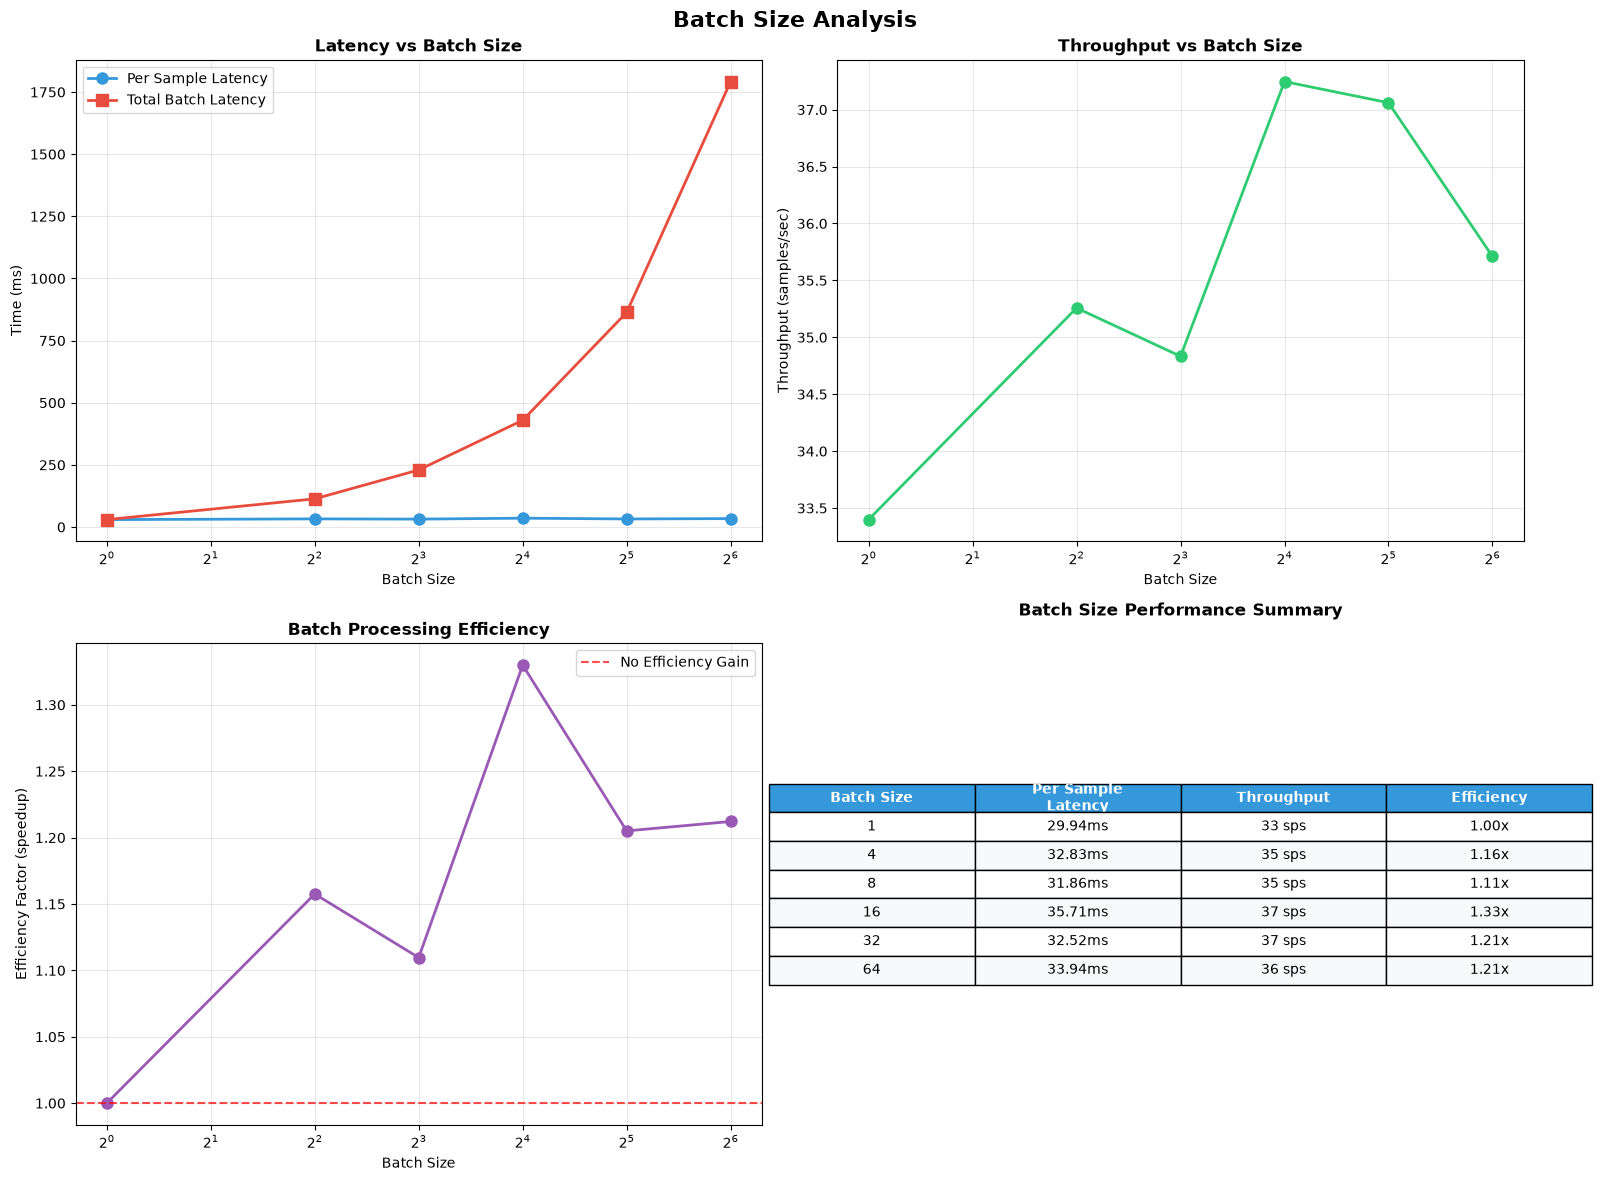


DEPLOYMENT OPTIMIZATION RESULTS:

   Mixed Precision (FP16):
     Tensor Core Eligible: 89.6%
     Estimated FLOP improvements: 0.0MB
     Estimated Speedup: 2.4x
     Estimated Throughput improvements %: 135.4%
     Estimated Memory Savings: 477.7MB
     Estimated Sensitivity Risk: Low - FP16 with FP32 accumulation is standard for CNN inference; validate sensitivity at the clinical threshold after conversion

   Deployment Scenarios:
     Real Time Diagnosis:
       Optimal Batch Size: 1
       Use Case: Emergency diagnosis, single patient processing
     Batch Processing:
       Optimal Batch Size: 16
       Use Case: Screening workflows, research processing


In [24]:
# Run the complete deployment optimization analysis with all 2 implemented analysis functions above
def run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results):
    """
    Main function to run all deployment optimization analyses.
    """
    print("Running Deployment Optimization Analysis...")

    # Analyze mixed precision potential
    mixed_precision = analyze_mixed_precision_potential(detailed_results)
    mixed_precision_speedup = mixed_precision['estimated_speedup']
    
    # Analyze batch processing scenarios
    batch_results, batch_scenarios = analyze_batch_processing_scenarios(baseline_model, mixed_precision_speedup)

    # Visualize batch size analysis for deployment understanding
    plot_batch_size_comparison(batch_results)

    # Calculate deployment readiness
    current_latency = timing_results['single_sample_ms']
    current_throughput = timing_results['throughput_samples_per_sec']
    
    performance_metrics = {
        'latency_ms': current_latency,
        'throughput_samples_sec': current_throughput
    }
    
    return {
        'mixed_precision': mixed_precision,
        'batch_scenarios': batch_scenarios
    }

# Execute deployment analysis
deployment_analysis = run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results)

print(f"\nDEPLOYMENT OPTIMIZATION RESULTS:")
mp_details = deployment_analysis['mixed_precision']
print(f"\n   Mixed Precision (FP16):")
print(f"     Tensor Core Eligible: {mp_details['mixed_precision_coverage_percent']:.1f}%")
print(f"     Estimated FLOP improvements: {mp_details['avg_flop_reduction_percent']:.1f}MB")
print(f"     Estimated Speedup: {mp_details['estimated_speedup']:.1f}x")
print(f"     Estimated Throughput improvements %: {mp_details['throughput_improvement_percent']:.1f}%")
print(f"     Estimated Memory Savings: {mp_details['estimated_memory_reduction_mb']:.1f}MB")
print(f"     Estimated Sensitivity Risk: {mp_details['sensitivity_risk']}")

if 'error' not in deployment_analysis['batch_scenarios']:
    scenarios = deployment_analysis['batch_scenarios']
    print(f"\n   Deployment Scenarios:")
    for scenario, details in scenarios.items():
        print(f"     {scenario.replace('_', ' ').title()}:")
        print(f"       Optimal Batch Size: {details['optimal_batch_size']}")
        print(f"       Use Case: {details['use_case']}")

> **_Before you move on...brainstorming time!_**
> 
> Based on your deployment analysis results above, collect your thoughts about hardware deployment opportunities - this will help you in completing your optimization plan at the end of the notebook:
>  
> 1. **Shared-Resource Constraints**: What is the main limiting factor when deploying the model alongside other applications—memory or compute?
> 
> 2. **Batch processing trade-offs**: How does performance change with batch size? What's the optimal configuration for different deployment scenarios?
> 
> 3. **Mixed precision impact**: What percentage of operations can benefit from FP16? How much speedup can you realistically expect? What are the implementation risks?
> 
> 4. **Production Readiness Assessment**: Which KPI targets can be met with hardware acceleration alone?

## **Congratulations!**

You have completed the model baseline analysis! This foundational work will guide all subsequent optimization efforts.

### **Summary: Key findings**

*All measurements below were taken on the CPU-only development machine (8 cores, torch 2.3.0+cpu); the production targets are defined for the T4 reference GPU, so absolute timings here are pessimistic while the relative analysis (FLOPs, memory composition, operation mix) transfers directly.*

1.  **Overall performance profile**:

The trained ResNet-18 baseline (11.2M parameters, 42.6 MB in FP32) reaches strong clinical performance - 100% sensitivity at threshold 0.4 (AUC 0.969) - but fails every efficiency target: 1.82 GFLOPs/sample vs the <0.4 GFLOPs target (4.5x over), 33.1 ms single-image latency and 37.6 samples/sec batch throughput on this machine vs the <3 ms / >2000 samples/sec targets, and roughly 913 MB of layer activations for a 32-image batch vs the <100 MB memory budget.

Without optimization the targets are out of reach even on the T4; with the roadmap below they are achievable, because ~92% of the compute is an artifact of input upscaling rather than useful work.

2. **Bottlenecks**:

The model is squarely **compute-bound in convolutions**: 89.1% of inference time (PyTorch profiler) and 99.7% of FLOPs are convolution work, with pooling (4.9%) and batch norm (3.8%) far behind. Memory is dominated by **activations, not parameters**: 912.8 MB of layer outputs vs 42.6 MB of weights (parameters are ~4% of the footprint), with the single largest activation (conv1's 64x112x112 map, 98 MB per batch) set by input resolution. The root cause of both is the hidden `F.interpolate` in `forward()`: every 64x64 image is bilinearly upscaled to 224x224 (12.25x more pixels), inflating every convolution and every activation map downstream while adding zero diagnostic information - this is the single biggest optimization opportunity.

3. **Architecture optimization** (Analysis Checkpoint 1):

Top 2 techniques by measured opportunity:
- **Interpolation removal (native 64x64 processing)**: 91.8% FLOP reduction (1.82 → 0.149 GFLOPs/sample, immediately meeting the <0.4 GFLOPs target), ~838 MB activation memory saved, conservatively estimated 1.96x wall-clock speedup (Amdahl-limited; the FLOP cut suggests substantially more in practice). Trivial to implement (bypass one resize), low clinical risk - upscaling a 64x64 source cannot add information - but requires retraining at native resolution.
- **Depthwise separable convolutions**: 16 candidate layers, 88.2% average parameter reduction, 81.5% FLOP reduction, estimated 2.19x speedup after the 0.6x hardware-efficiency penalty for memory-bound depthwise kernels. Moderate effort (drop-in layer swap + retraining); MobileNet-class accuracy is recoverable on this comparatively easy binary task.

Techniques analyzed and deprioritized: **grouped convolutions** (46.2% FLOP cut, est. 1.26x) are a strictly weaker version of depthwise separation; **inverted residuals** (est. 1.27x) require a full block redesign for less gain than the two picks; **channel organization** (channels_last + in-place ReLU, est. 1.05x, zero risk) is worth taking as a free add-on - torchvision's ReLUs are already in-place, so the gain is layout-only; **parameter sharing** (25% of weights shareable) carries high accuracy risk for pure-memory savings we do not need once activations shrink; **low-rank factorization is not applicable** - the only linear layer is the 512→2 head (~1k parameters), below any threshold where factorization pays.

4. **Hardware deployment optimization** (Analysis Checkpoint 2):

- **Mixed precision (FP16)**: 89.6% of runtime is Tensor-Core-eligible (convolutions + matmuls), giving a research-backed estimate of ~2.4x speedup and ~478 MB memory savings on the T4. Risk is low (FP16 with FP32 accumulation), gated on re-validating sensitivity at the clinical threshold.
- **Batch configuration**: batch 1 is optimal for real-time diagnosis (lowest single-call latency); batch 16 maximized throughput in the sweep on this machine, with FP16 projected to roughly double it. Larger batches saturate memory bandwidth without throughput gains here; on the T4 the optimum will sit higher (16-64) and should be re-swept after optimization.

### **Recommended optimization roadmap**

**Phase 1 (Quick Wins):**

- *Architecture*: **Remove the 64→224 interpolation** and retrain at native resolution - one-line change, 91.8% FLOP cut, meets the <0.4 GFLOPs target outright (0.149 GFLOPs/sample).
- *Hardware*: **Enable FP16 mixed precision** for T4 deployment (est. 2.4x, ~50% memory) with sensitivity re-validation.

*Estimated Phase 1 impact*: ~12x less convolution compute and ~2x from precision multiply into an expected 4-5x+ end-to-end speedup and >90% activation-memory reduction - GFLOPs and memory targets met, latency/throughput within reach on the reference T4.

**Phase 2 (Extra Impact):**

- *Architecture*: **Convert the 16 dense 3x3 convolutions to depthwise separable** (88.2% parameter cut, ~0.03 GFLOPs/sample final) and adopt **channels_last** memory format as a free hardware-affinity win.
- *Hardware*: re-sweep batch sizes on the T4 post-optimization and pin the throughput configuration (expected 16-64).

*Estimated Phase 2 impact*: a further ~2x latency improvement and ~9x parameter reduction (11.2M → ~1.3M), securing the >2000 samples/sec throughput target with margin while keeping sensitivity ≥98% through retraining and threshold selection.

---

**You are now ready to move to Notebook 2: Architecture Optimization!**
